In [ ]:
install.packages("sqldf")
library(sqldf)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite



In [ ]:
install.packages("sqldf",     repos = "https://cran.r-project.org", quiet = TRUE)
install.packages("dplyr",     repos = "https://cran.r-project.org", quiet = TRUE)
install.packages("ggplot2",   repos = "https://cran.r-project.org", quiet = TRUE)
install.packages("lubridate", repos = "https://cran.r-project.org", quiet = TRUE)

cat("✅ All packages installed\n")

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’




✅ All packages installed


In [ ]:
library(sqldf)
library(dplyr)
library(ggplot2)
library(lubridate)

cat("✅ Libraries loaded\n")

Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




✅ Libraries loaded


In [ ]:
customers  <- read.csv("customers.csv",  stringsAsFactors = FALSE, na.strings = c("", "NA"))
orders     <- read.csv("orders.csv",     stringsAsFactors = FALSE, na.strings = c("", "NA"))
deliveries <- read.csv("deliveries.csv", stringsAsFactors = FALSE, na.strings = c("", "NA"))
drivers    <- read.csv("drivers.csv",    stringsAsFactors = FALSE, na.strings = c("", "NA"))
vehicles   <- read.csv("vehicles.csv",   stringsAsFactors = FALSE, na.strings = c("", "NA"))
hubs       <- read.csv("hubs.csv",       stringsAsFactors = FALSE, na.strings = c("", "NA"))
complaints <- read.csv("complaints.csv", stringsAsFactors = FALSE, na.strings = c("", "NA"))
incidents  <- read.csv("incidents.csv",  stringsAsFactors = FALSE, na.strings = c("", "NA"))
app_events <- read.csv("app_events.csv", stringsAsFactors = FALSE, na.strings = c("", "NA"))

cat("✅ All files loaded\n")
cat(sprintf("customers:  %d rows\n", nrow(customers)))
cat(sprintf("orders:     %d rows\n", nrow(orders)))
cat(sprintf("deliveries: %d rows\n", nrow(deliveries)))
cat(sprintf("drivers:    %d rows\n", nrow(drivers)))
cat(sprintf("vehicles:   %d rows\n", nrow(vehicles)))
cat(sprintf("hubs:       %d rows\n", nrow(hubs)))
cat(sprintf("complaints: %d rows\n", nrow(complaints)))
cat(sprintf("incidents:  %d rows\n", nrow(incidents)))
cat(sprintf("app_events: %d rows\n", nrow(app_events)))

✅ All files loaded
customers:  650 rows
orders:     1250 rows
deliveries: 950 rows
drivers:    170 rows
vehicles:   120 rows
hubs:       8 rows
complaints: 320 rows
incidents:  280 rows
app_events: 640 rows


In [ ]:
# The dataset has inconsistent zone names like "north", "NORTH", "North"
# We fix this before running any queries

clean_text <- function(x) {
  x <- trimws(x)
  x <- toupper(x)
  return(x)
}

customers$home_zone     <- clean_text(customers$home_zone)
orders$pickup_zone      <- clean_text(orders$pickup_zone)
orders$dropoff_zone     <- clean_text(orders$dropoff_zone)
drivers$base_zone       <- clean_text(drivers$base_zone)
vehicles$assigned_zone  <- clean_text(vehicles$assigned_zone)
hubs$zone               <- clean_text(hubs$zone)
app_events$zone_context <- clean_text(app_events$zone_context)

deliveries$delivery_status <- trimws(deliveries$delivery_status)
complaints$status          <- trimws(complaints$status)
complaints$severity        <- trimws(complaints$severity)
incidents$severity         <- trimws(incidents$severity)

app_events$zone_context <- gsub("^CTR$", "CENTRAL", app_events$zone_context)

cat("✅ Data cleaning done\n")
cat("Unique delivery statuses:\n")
print(unique(deliveries$delivery_status))

✅ Data cleaning done
Unique delivery statuses:
[1] "Failed"  "OnTime"  "Delayed"


In [ ]:
query1_result <- sqldf("
  SELECT
    h.hub_id,
    h.hub_name,
    h.zone,
    h.hub_type,
    COUNT(d.delivery_id) AS total_deliveries,
    SUM(CASE WHEN d.delivery_status = 'Failed'  THEN 1 ELSE 0 END) AS failed_count,
    SUM(CASE WHEN d.delivery_status = 'Delayed' THEN 1 ELSE 0 END) AS delayed_count,
    SUM(CASE WHEN d.delivery_status = 'OnTime'  THEN 1 ELSE 0 END) AS ontime_count,
    ROUND(
      100.0 * SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END)
      / COUNT(d.delivery_id), 1
    ) AS failure_rate_pct
  FROM deliveries d
  JOIN hubs h ON d.hub_id = h.hub_id
  GROUP BY h.hub_id, h.hub_name, h.zone, h.hub_type
  ORDER BY failure_rate_pct DESC
")

cat("=== Query 1: Delivery Failure Rate by Hub ===\n\n")
print(query1_result)

=== Query 1: Delivery Failure Rate by Hub ===

  hub_id       hub_name      zone  hub_type total_deliveries failed_count
1    H08  Midtown Relay   CENTRAL  Charging              128           26
2    H05   Central Core   CENTRAL   Control              115           23
3    H06    Airport Hub   AIRPORT  Dispatch              104           15
4    H04      West Gate      WEST  Dispatch              127           16
5    H01 North Exchange     NORTH  Dispatch              136           17
6    H07  Riverside Hub RIVERSIDE Warehouse              115           14
7    H02     South Link     SOUTH  Dispatch              106           10
8    H03      East Dock      EAST Warehouse              119           11
  delayed_count ontime_count failure_rate_pct
1            22           80             20.3
2            25           67             20.0
3            27           62             14.4
4            28           83             12.6
5            26           93             12.5
6          

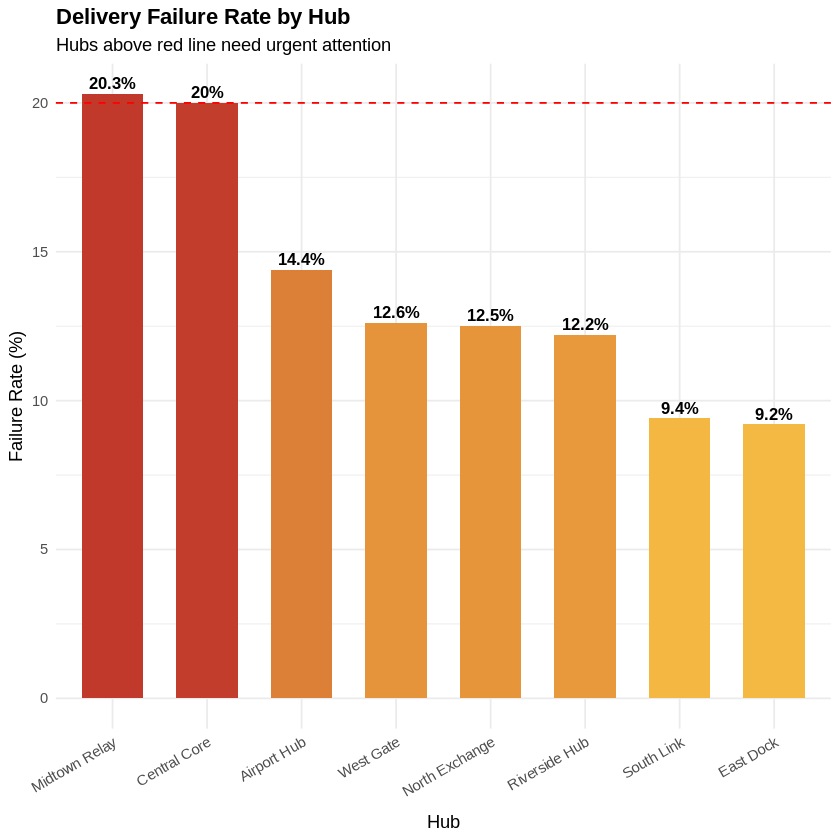

In [ ]:
ggplot(query1_result, aes(x = reorder(hub_name, -failure_rate_pct),
                           y = failure_rate_pct,
                           fill = failure_rate_pct)) +
  geom_bar(stat = "identity", width = 0.65) +
  geom_text(aes(label = paste0(failure_rate_pct, "%")),
            vjust = -0.4, size = 3.5, fontface = "bold") +
  scale_fill_gradient(low = "#F4B942", high = "#C0392B") +
  geom_hline(yintercept = 20, linetype = "dashed", colour = "red") +
  labs(
    title    = "Delivery Failure Rate by Hub",
    subtitle = "Hubs above red line need urgent attention",
    x = "Hub", y = "Failure Rate (%)"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 30, hjust = 1),
        legend.position = "none",
        plot.title = element_text(face = "bold"))

In [ ]:
query2_result <- sqldf("
  SELECT
    c.customer_id,
    c.customer_type,
    c.home_zone,
    c.loyalty_score,
    c.account_status,
    COUNT(cp.complaint_id) AS open_complaint_count,
    SUM(CASE WHEN cp.severity = 'High' THEN 1 ELSE 0 END) AS high_severity_count,
    ROUND(SUM(cp.compensation_amount), 2) AS total_compensation_paid,
    MAX(cp.resolution_days) AS max_resolution_days
  FROM customers c
  JOIN complaints cp ON c.customer_id = cp.customer_id
  WHERE cp.status = 'Open'
    AND c.loyalty_score > 70
  GROUP BY c.customer_id, c.customer_type, c.home_zone,
           c.loyalty_score, c.account_status
  ORDER BY high_severity_count DESC, c.loyalty_score DESC
")

cat("=== Query 2: High-Value Customers with Open Complaints ===\n\n")
cat(sprintf("Total at-risk customers: %d\n\n", nrow(query2_result)))
print(query2_result)

=== Query 2: High-Value Customers with Open Complaints ===

Total at-risk customers: 15

   customer_id customer_type home_zone loyalty_score account_status
1        C0583      Consumer   AIRPORT          84.2        Dormant
2        C0566      Consumer   CENTRAL          75.4         Active
3        C0252      Consumer     NORTH          71.3         Active
4        C0146      Consumer     NORTH          99.0         Active
5        C0014      Consumer     NORTH          94.1         Active
6        C0345      Consumer     NORTH          93.5         Active
7        C0161      Consumer     NORTH          87.1         Active
8        C0242      Consumer      EAST          83.8         Active
9        C0465      Consumer   AIRPORT          82.4         Active
10       C0140      Consumer   AIRPORT          80.0         Active
11       C0028      Consumer       CTR          78.5         Active
12       C0575      Consumer RIVERSIDE          77.2         Active
13       C0381      Consume

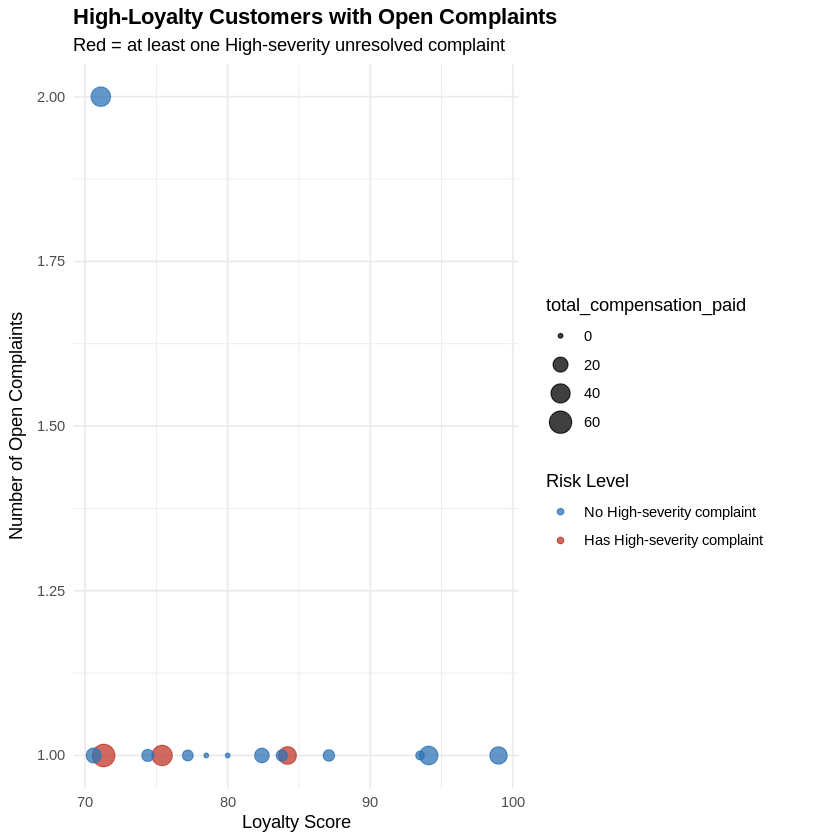

In [ ]:
ggplot(query2_result, aes(x = loyalty_score,
                           y = open_complaint_count,
                           colour = as.factor(high_severity_count > 0),
                           size   = total_compensation_paid)) +
  geom_point(alpha = 0.75) +
  scale_colour_manual(
    values = c("FALSE" = "#2E75B6", "TRUE" = "#C0392B"),
    labels = c("No High-severity complaint", "Has High-severity complaint"),
    name   = "Risk Level"
  ) +
  labs(
    title    = "High-Loyalty Customers with Open Complaints",
    subtitle = "Red = at least one High-severity unresolved complaint",
    x = "Loyalty Score", y = "Number of Open Complaints"
  ) +
  theme_minimal() +
  theme(plot.title = element_text(face = "bold"))

In [ ]:
query3_result <- sqldf("
  SELECT
    d.driver_id,
    d.base_zone,
    d.employment_type,
    d.driver_rating,
    d.training_score,
    COUNT(dl.delivery_id)                           AS total_deliveries,
    SUM(dl.manual_route_override_count)             AS total_overrides,
    ROUND(AVG(dl.manual_route_override_count), 2)   AS avg_overrides_per_job,
    ROUND(AVG(dl.customer_rating_post_delivery), 2) AS avg_customer_rating,
    SUM(CASE WHEN dl.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed_deliveries
  FROM drivers d
  JOIN deliveries dl ON d.driver_id = dl.driver_id
  GROUP BY d.driver_id, d.base_zone, d.employment_type,
           d.driver_rating, d.training_score
  HAVING total_overrides > 0
  ORDER BY total_overrides DESC
")

cat("=== Query 3: Driver Override Analysis ===\n\n")
print(head(query3_result, 20))

=== Query 3: Driver Override Analysis ===

   driver_id base_zone employment_type driver_rating training_score
1       D127   CENTRAL        FullTime          4.19           61.5
2       D087     NORTH        Contract          4.43           73.3
3       D130      WEST        FullTime          3.64           71.2
4       D108     SOUTH        FullTime          4.33           70.6
5       D131     SOUTH        FullTime          4.26           86.7
6       D069     NORTH        PartTime          5.00           61.5
7       D105 RIVERSIDE        Contract          3.71           82.0
8       D017      EAST        PartTime          4.34             NA
9       D028     NORTH        FullTime          4.07           83.0
10      D008     SOUTH        FullTime          3.88           84.1
11      D026     NORTH        PartTime          3.15           84.9
12      D104      WEST        FullTime          3.45           87.7
13      D027   AIRPORT        PartTime          3.70           74.3
14   

=== Correlation: Driver Rating vs Overrides ===

Correlation (r) : -0.0866
p-value         : 0.271667

⚠️ Not statistically significant — route planning may be the real cause


`geom_smooth()` using formula = 'y ~ x'


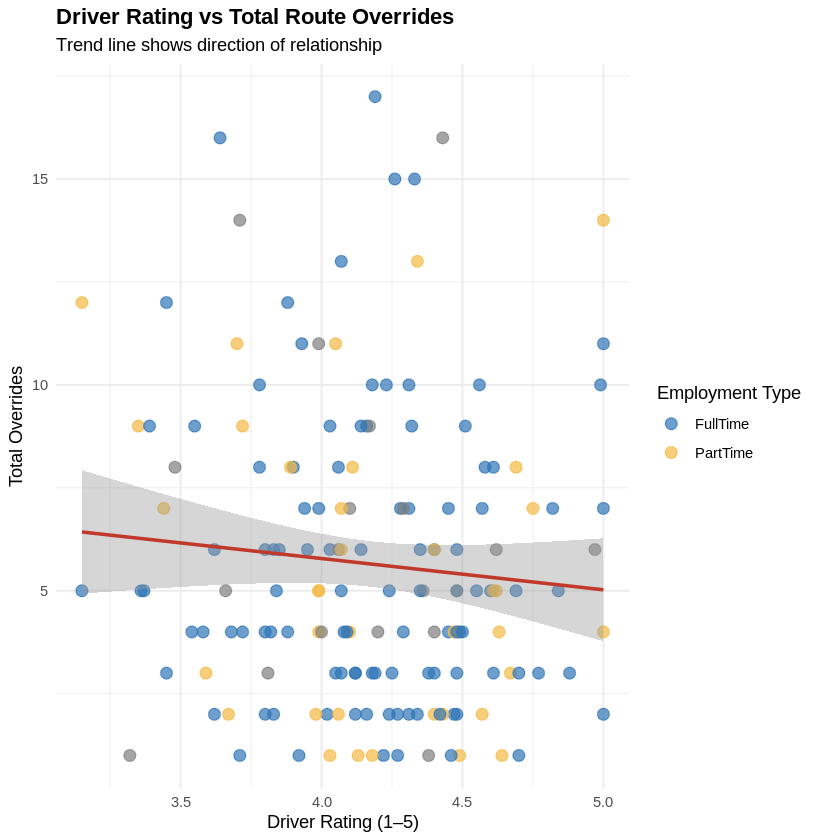

In [ ]:
cor_test <- cor.test(query3_result$driver_rating,
                     query3_result$total_overrides,
                     method = "pearson")

cat("=== Correlation: Driver Rating vs Overrides ===\n\n")
cat(sprintf("Correlation (r) : %.4f\n", cor_test$estimate))
cat(sprintf("p-value         : %.6f\n", cor_test$p.value))

if (cor_test$p.value < 0.05) {
  cat("\n✅ Statistically significant (p < 0.05)\n")
  if (cor_test$estimate < 0) {
    cat("Lower-rated drivers override routes MORE — possible performance avoidance\n")
  }
} else {
  cat("\n⚠️ Not statistically significant — route planning may be the real cause\n")
}

# Chart
ggplot(query3_result, aes(x = driver_rating, y = total_overrides)) +
  geom_point(aes(colour = employment_type), alpha = 0.7, size = 3) +
  geom_smooth(method = "lm", se = TRUE, colour = "#C0392B") +
  scale_colour_manual(values = c("FullTime" = "#2E75B6", "PartTime" = "#F4B942")) +
  labs(
    title = "Driver Rating vs Total Route Overrides",
    subtitle = "Trend line shows direction of relationship",
    x = "Driver Rating (1–5)", y = "Total Overrides",
    colour = "Employment Type"
  ) +
  theme_minimal() +
  theme(plot.title = element_text(face = "bold"))

In [ ]:
query4_result <- sqldf("
  SELECT
    v.vehicle_id,
    v.vehicle_type,
    v.assigned_zone,
    v.battery_health_pct,
    v.maintenance_status,
    v.odometer_km,
    COUNT(DISTINCT dl.delivery_id)        AS deliveries_completed,
    COUNT(i.incident_id)                  AS total_incidents,
    ROUND(AVG(i.resolved_hours), 1)       AS avg_resolve_hrs,
    SUM(CASE WHEN i.severity = 'High' THEN 1 ELSE 0 END) AS high_severity_incidents
  FROM vehicles v
  LEFT JOIN deliveries dl ON v.vehicle_id = dl.vehicle_id
  LEFT JOIN incidents  i  ON dl.delivery_id = i.delivery_id
  WHERE v.maintenance_status != 'Active'
     OR v.battery_health_pct < 65
     OR v.battery_health_pct IS NULL
  GROUP BY v.vehicle_id, v.vehicle_type, v.assigned_zone,
           v.battery_health_pct, v.maintenance_status, v.odometer_km
  ORDER BY total_incidents DESC, v.battery_health_pct ASC
")

cat("=== Query 4: Vehicle Risk Assessment ===\n\n")
cat(sprintf("At-risk vehicles: %d\n\n", nrow(query4_result)))
print(query4_result)

=== Query 4: Vehicle Risk Assessment ===

At-risk vehicles: 70

   vehicle_id vehicle_type assigned_zone battery_health_pct maintenance_status
1        V047           EV           CTR               93.7          Scheduled
2        V108       Diesel       AIRPORT               54.6           InRepair
3        V005     CargoVan          WEST               58.6             Active
4        V076       Diesel       CENTRAL               65.8           InRepair
5        V088       Diesel         NORTH               80.3           InRepair
6        V042           EV          EAST               80.5           InRepair
7        V025       Diesel       AIRPORT               42.0             Active
8        V012       Hybrid         SOUTH               56.2             Active
9        V100     CargoVan          EAST               60.1             Active
10       V109       Hybrid       AIRPORT               60.6           InRepair
11       V043           EV         SOUTH               76.4        

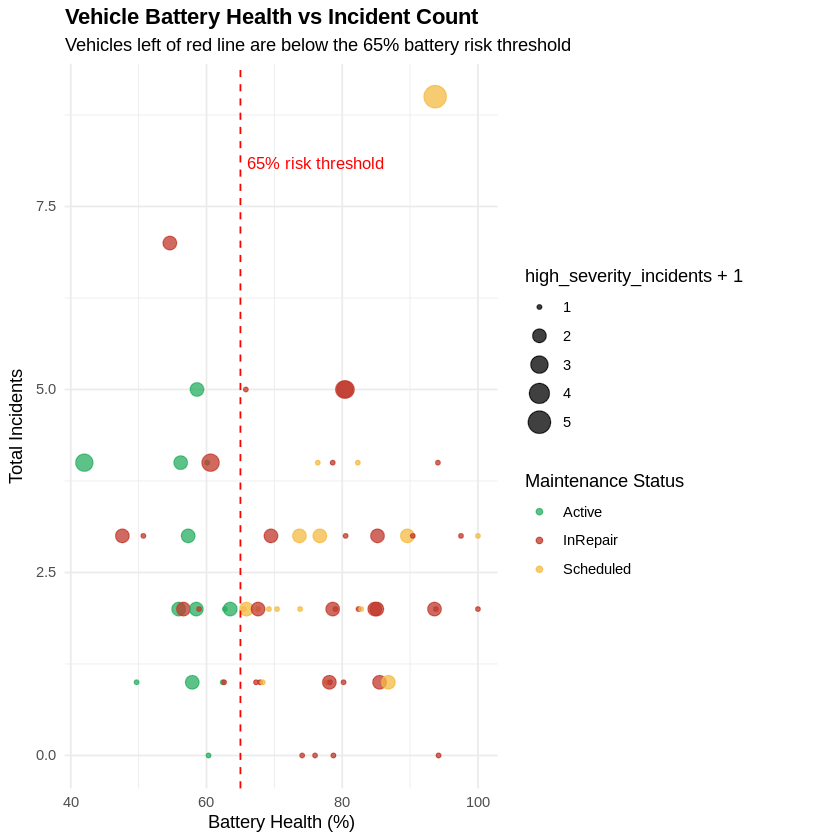

In [ ]:
plot_data <- query4_result[!is.na(query4_result$battery_health_pct), ]

ggplot(plot_data, aes(x = battery_health_pct,
                       y = total_incidents,
                       colour = maintenance_status,
                       size   = high_severity_incidents + 1)) +
  geom_point(alpha = 0.75) +
  geom_vline(xintercept = 65, linetype = "dashed", colour = "red") +
  annotate("text", x = 66, y = max(plot_data$total_incidents) * 0.9,
           label = "65% risk threshold", colour = "red", size = 3.5, hjust = 0) +
  scale_colour_manual(values = c("Active" = "#27AE60",
                                  "InRepair" = "#C0392B",
                                  "Scheduled" = "#F4B942")) +
  labs(
    title    = "Vehicle Battery Health vs Incident Count",
    subtitle = "Vehicles left of red line are below the 65% battery risk threshold",
    x = "Battery Health (%)", y = "Total Incidents",
    colour = "Maintenance Status"
  ) +
  theme_minimal() +
  theme(plot.title = element_text(face = "bold"))

In [ ]:
query5_result <- sqldf("
  SELECT
    o.service_type,
    o.pickup_zone,
    COUNT(o.order_id)                              AS total_orders,
    ROUND(AVG(o.order_value), 2)                   AS avg_order_value,
    ROUND(AVG(d.fuel_or_charge_cost), 2)           AS avg_delivery_cost,
    ROUND(AVG(o.order_value) - AVG(d.fuel_or_charge_cost), 2) AS avg_gross_margin,
    ROUND(100.0 * (AVG(o.order_value) - AVG(d.fuel_or_charge_cost))
          / AVG(o.order_value), 1)                 AS margin_pct,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failures
  FROM orders o
  JOIN deliveries d ON o.order_id = d.order_id
  GROUP BY o.service_type, o.pickup_zone
  HAVING total_orders >= 5
  ORDER BY avg_gross_margin DESC
")

cat("=== Query 5: Service Profitability by Type and Zone ===\n\n")
print(query5_result)

loss_making <- query5_result[query5_result$avg_gross_margin < 0, ]
cat(sprintf("\n🔴 Loss-making combinations: %d\n", nrow(loss_making)))
if (nrow(loss_making) > 0) print(loss_making)

=== Query 5: Service Profitability by Type and Zone ===

   service_type pickup_zone total_orders avg_order_value avg_delivery_cost
1      Business         CTR           12          122.10             12.02
2      Business     CENTRAL           12          115.46             10.22
3     Passenger        EAST           45          115.07             11.79
4     Passenger     AIRPORT           30          116.66             16.11
5      Business   RIVERSIDE           17          108.12             12.61
6     Passenger        WEST           32          103.64             11.70
7       Medical   RIVERSIDE           14          103.36             12.98
8        Retail       NORTH           32          101.14             12.11
9      Business       NORTH           23          101.40             12.47
10       Parcel     AIRPORT           31          103.35             16.75
11       Parcel         CTR           15           97.96             11.62
12       Retail   RIVERSIDE           27   

Descriptive Statistics by Service Type

In [ ]:
# Summary statistics for order values grouped by service type
# This tells the Finance Director which services generate the most revenue

order_stats <- orders %>%
  group_by(service_type) %>%
  summarise(
    count        = n(),
    mean_value   = round(mean(order_value,   na.rm = TRUE), 2),
    median_value = round(median(order_value, na.rm = TRUE), 2),
    sd_value     = round(sd(order_value,     na.rm = TRUE), 2),
    min_value    = round(min(order_value,    na.rm = TRUE), 2),
    max_value    = round(max(order_value,    na.rm = TRUE), 2)
  ) %>%
  arrange(desc(mean_value))

cat("=== Descriptive Statistics: Order Value by Service Type ===\n\n")
print(order_stats)

=== Descriptive Statistics: Order Value by Service Type ===

# A tibble: 5 × 7
  service_type count mean_value median_value sd_value min_value max_value
  <chr>        <int>      <dbl>        <dbl>    <dbl>     <dbl>     <dbl>
1 Passenger      341       96.1         81.9     61.6      5.92      326.
2 Business       165       92.2         79.8     61.7      6.28      322.
3 Retail         297       90.0         75.2     60.5      4.22      356.
4 Parcel         308       87.6         73.6     60.7      3.57      510.
5 Medical        139       87.1         71.3     59.9      2.04      292.


Chart: Order Value Distribution

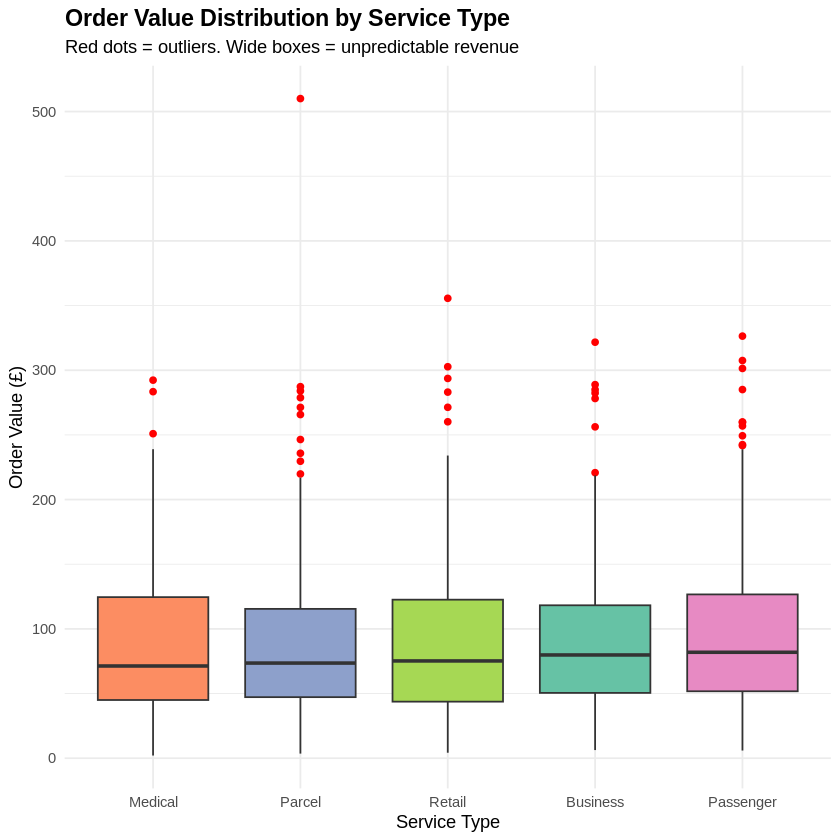

In [ ]:
# Box plot showing spread of order values per service type
# A wide box = unpredictable revenue, narrow box = consistent revenue

ggplot(orders, aes(x = reorder(service_type, order_value, median),
                    y = order_value,
                    fill = service_type)) +
  geom_boxplot(outlier.colour = "red", outlier.size = 1.5) +
  scale_fill_brewer(palette = "Set2") +
  labs(
    title    = "Order Value Distribution by Service Type",
    subtitle = "Red dots = outliers. Wide boxes = unpredictable revenue",
    x        = "Service Type",
    y        = "Order Value (£)"
  ) +
  theme_minimal() +
  theme(
    plot.title     = element_text(face = "bold", size = 14),
    legend.position = "none"
  )

 Delivery Outcomes by Zone

In [ ]:
# Join deliveries with hubs to get zone info
# Then calculate how many OnTime / Delayed / Failed per zone

delivery_zone <- deliveries %>%
  left_join(hubs, by = "hub_id") %>%
  filter(!is.na(delivery_status), !is.na(zone))

zone_outcomes <- delivery_zone %>%
  group_by(zone, delivery_status) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(zone) %>%
  mutate(proportion = round(count / sum(count) * 100, 1))

cat("=== Delivery Outcomes by Zone ===\n\n")
print(zone_outcomes)

=== Delivery Outcomes by Zone ===

# A tibble: 21 × 4
# Groups:   zone [7]
   zone    delivery_status count proportion
   <chr>   <chr>           <int>      <dbl>
 1 AIRPORT Delayed            27       26  
 2 AIRPORT Failed             15       14.4
 3 AIRPORT OnTime             62       59.6
 4 CENTRAL Delayed            47       19.3
 5 CENTRAL Failed             49       20.2
 6 CENTRAL OnTime            147       60.5
 7 EAST    Delayed            23       19.3
 8 EAST    Failed             11        9.2
 9 EAST    OnTime             85       71.4
10 NORTH   Delayed            26       19.1
# ℹ 11 more rows


Chart: Delivery Outcomes by Zone

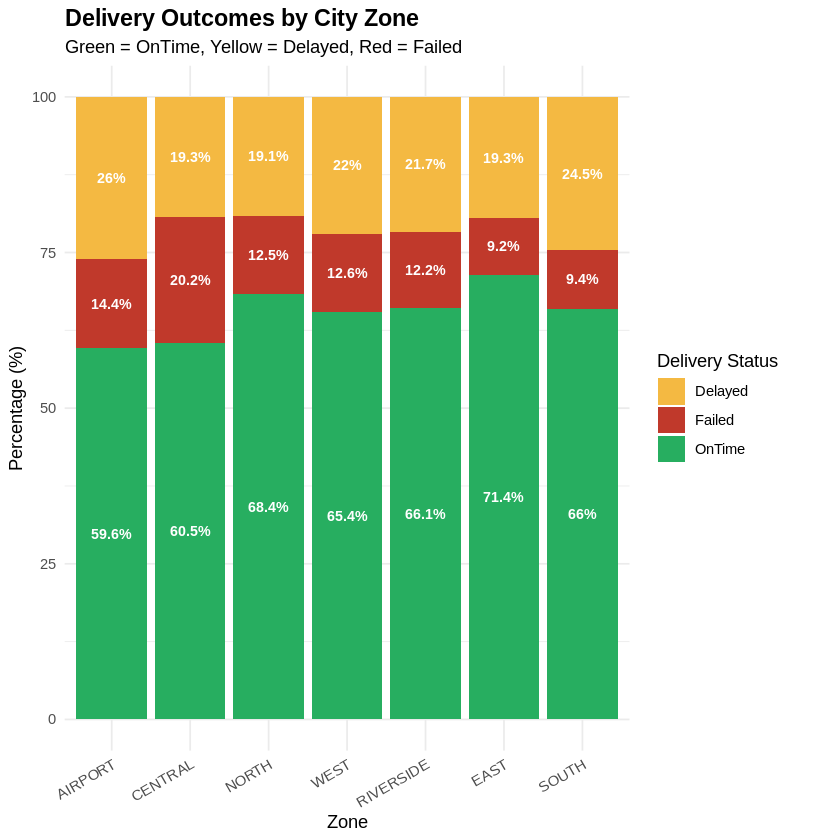

In [ ]:
# Stacked bar chart — shows which zones have the worst performance
# This directly answers the Operations Director's question

ggplot(zone_outcomes, aes(x = reorder(zone, -proportion),
                           y = proportion,
                           fill = delivery_status)) +
  geom_bar(stat = "identity", position = "stack") +
  scale_fill_manual(values = c(
    "OnTime"  = "#27AE60",
    "Delayed" = "#F4B942",
    "Failed"  = "#C0392B"
  )) +
  geom_text(aes(label = paste0(proportion, "%")),
            position = position_stack(vjust = 0.5),
            size = 3, colour = "white", fontface = "bold") +
  labs(
    title    = "Delivery Outcomes by City Zone",
    subtitle = "Green = OnTime, Yellow = Delayed, Red = Failed",
    x        = "Zone",
    y        = "Percentage (%)",
    fill     = "Delivery Status"
  ) +
  theme_minimal() +
  theme(
    plot.title    = element_text(face = "bold", size = 14),
    axis.text.x   = element_text(angle = 30, hjust = 1)
  )

Complaint Volume Over Time

In [ ]:
# Parse the date column and group complaints by week
# Shows whether complaints are getting worse over time

complaints$created_at <- as.POSIXct(complaints$created_at, format = "%Y-%m-%d %H:%M:%S")
complaints$week       <- floor_date(complaints$created_at, "month")

monthly_complaints <- complaints %>%
  group_by(week, severity) %>%
  summarise(count = n(), .groups = "drop")

cat("=== Monthly Complaint Volume by Severity ===\n\n")
print(monthly_complaints)

=== Monthly Complaint Volume by Severity ===

# A tibble: 70 × 3
   week                severity count
   <dttm>              <chr>    <int>
 1 2024-01-01 00:00:00 High         5
 2 2024-01-01 00:00:00 Low          3
 3 2024-01-01 00:00:00 Medium       8
 4 2024-02-01 00:00:00 High         2
 5 2024-02-01 00:00:00 Low          3
 6 2024-02-01 00:00:00 Medium       4
 7 2024-03-01 00:00:00 High         9
 8 2024-03-01 00:00:00 Low          5
 9 2024-03-01 00:00:00 Medium       6
10 2024-04-01 00:00:00 High         4
# ℹ 60 more rows


Chart: Complaint Trend Over Time

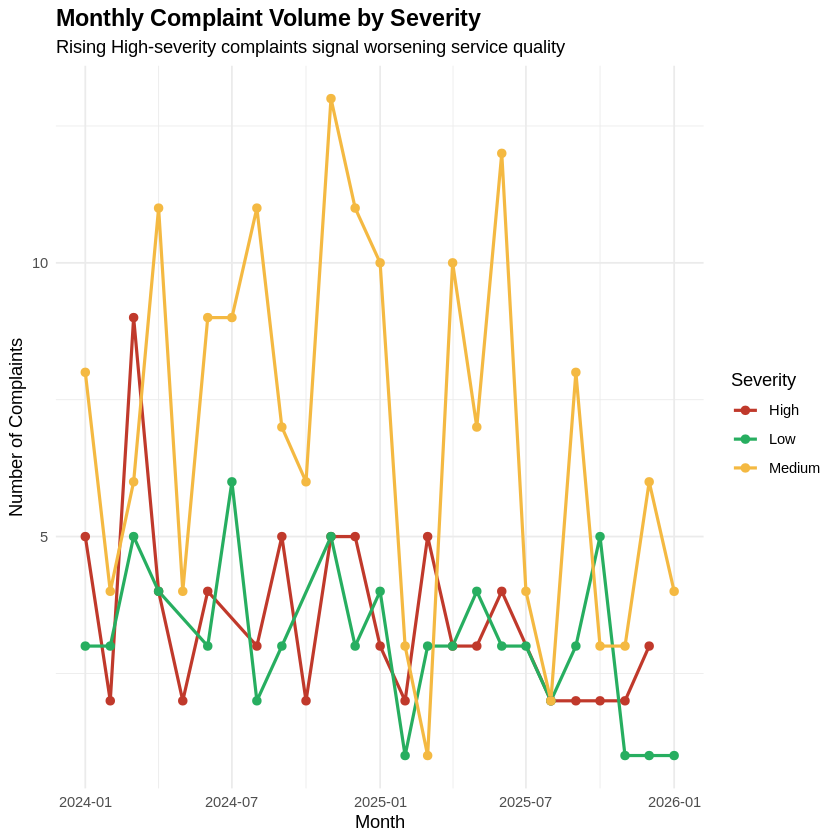

In [ ]:
ggplot(monthly_complaints, aes(x = week, y = count, colour = severity)) +
  geom_line(linewidth = 0.9) +
  geom_point(size = 2) +
  scale_colour_manual(values = c(
    "High"   = "#C0392B",
    "Medium" = "#F4B942",
    "Low"    = "#27AE60"
  )) +
  labs(
    title    = "Monthly Complaint Volume by Severity",
    subtitle = "Rising High-severity complaints signal worsening service quality",
    x        = "Month",
    y        = "Number of Complaints",
    colour   = "Severity"
  ) +
  theme_minimal() +
  theme(plot.title = element_text(face = "bold", size = 14))

Customer Loyalty vs Complaint Count

In [ ]:
# Count how many complaints each customer has
# Then join with customer data to see if loyal customers complain more

complaint_counts <- complaints %>%
  group_by(customer_id) %>%
  summarise(
    total_complaints   = n(),
    high_severity      = sum(severity == "High", na.rm = TRUE),
    avg_resolution_days = round(mean(resolution_days, na.rm = TRUE), 1),
    total_compensation  = round(sum(compensation_amount, na.rm = TRUE), 2)
  )

customer_analysis <- customers %>%
  left_join(complaint_counts, by = "customer_id") %>%
  mutate(total_complaints = ifelse(is.na(total_complaints), 0, total_complaints))

cat("=== Customer Analysis Summary ===\n\n")
cat(sprintf("Customers with zero complaints : %d\n",
    sum(customer_analysis$total_complaints == 0)))
cat(sprintf("Customers with 1+ complaints  : %d\n",
    sum(customer_analysis$total_complaints > 0)))
cat(sprintf("Average loyalty score overall : %.1f\n",
    mean(customer_analysis$loyalty_score, na.rm = TRUE)))

=== Customer Analysis Summary ===

Customers with zero complaints : 417
Customers with 1+ complaints  : 233
Average loyalty score overall : 59.7


Chart: Loyalty Score vs Complaints

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 9 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 9 rows containing missing values or values outside the scale range
(`geom_point()`).”


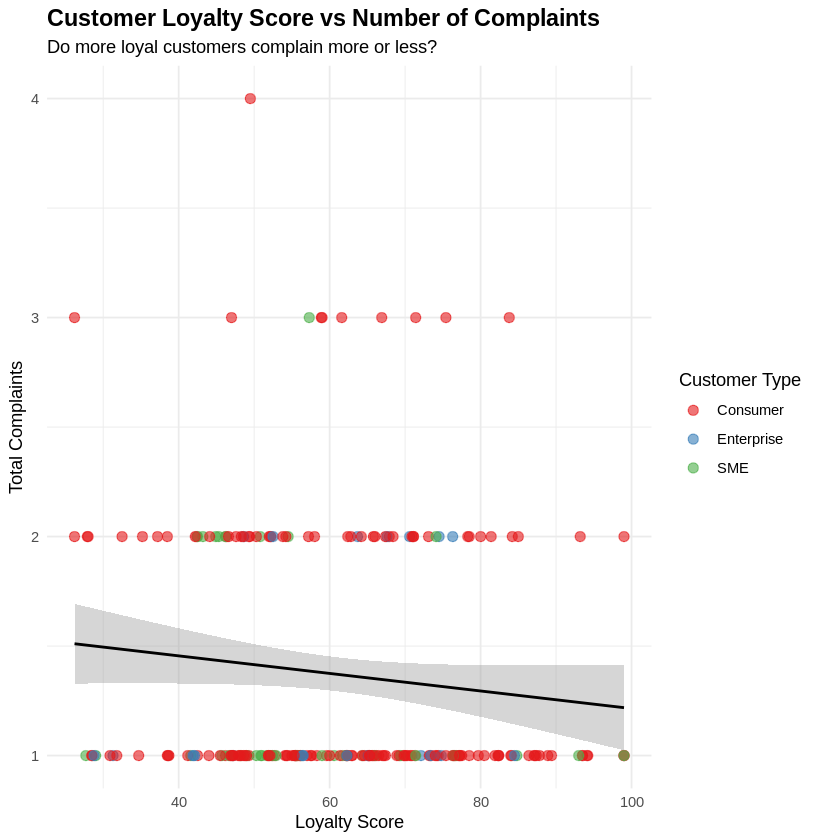

In [ ]:
ggplot(customer_analysis %>% filter(total_complaints > 0),
       aes(x = loyalty_score,
           y = total_complaints,
           colour = customer_type)) +
  geom_point(alpha = 0.6, size = 2.5) +
  geom_smooth(method = "lm", se = TRUE, colour = "black", linewidth = 0.8) +
  scale_colour_brewer(palette = "Set1", name = "Customer Type") +
  labs(
    title    = "Customer Loyalty Score vs Number of Complaints",
    subtitle = "Do more loyal customers complain more or less?",
    x        = "Loyalty Score",
    y        = "Total Complaints"
  ) +
  theme_minimal() +
  theme(plot.title = element_text(face = "bold", size = 14))

Driver Performance Statistical Summary

In [ ]:
# Full statistical breakdown of driver performance
# Grouped by employment type and zone

driver_performance <- drivers %>%
  left_join(
    deliveries %>%
      group_by(driver_id) %>%
      summarise(
        total_jobs       = n(),
        total_overrides  = sum(manual_route_override_count, na.rm = TRUE),
        failed_jobs      = sum(delivery_status == "Failed", na.rm = TRUE),
        avg_cust_rating  = round(mean(customer_rating_post_delivery, na.rm = TRUE), 2),
        .groups          = "drop"
      ),
    by = "driver_id"
  )

performance_summary <- driver_performance %>%
  group_by(employment_type) %>%
  summarise(
    driver_count      = n(),
    avg_driver_rating = round(mean(driver_rating,    na.rm = TRUE), 2),
    avg_training_score= round(mean(training_score,   na.rm = TRUE), 2),
    avg_overrides     = round(mean(total_overrides,  na.rm = TRUE), 2),
    avg_failed_jobs   = round(mean(failed_jobs,      na.rm = TRUE), 2),
    avg_cust_rating   = round(mean(avg_cust_rating,  na.rm = TRUE), 2)
  )

cat("=== Driver Performance by Employment Type ===\n\n")
print(performance_summary)

=== Driver Performance by Employment Type ===

# A tibble: 3 × 7
  employment_type driver_count avg_driver_rating avg_training_score
  <chr>                  <int>             <dbl>              <dbl>
1 Contract                  20              4.09               73.3
2 FullTime                 110              4.17               75.6
3 PartTime                  40              4.22               73.6
# ℹ 3 more variables: avg_overrides <dbl>, avg_failed_jobs <dbl>,
#   avg_cust_rating <dbl>


Chart: Driver Rating Distribution

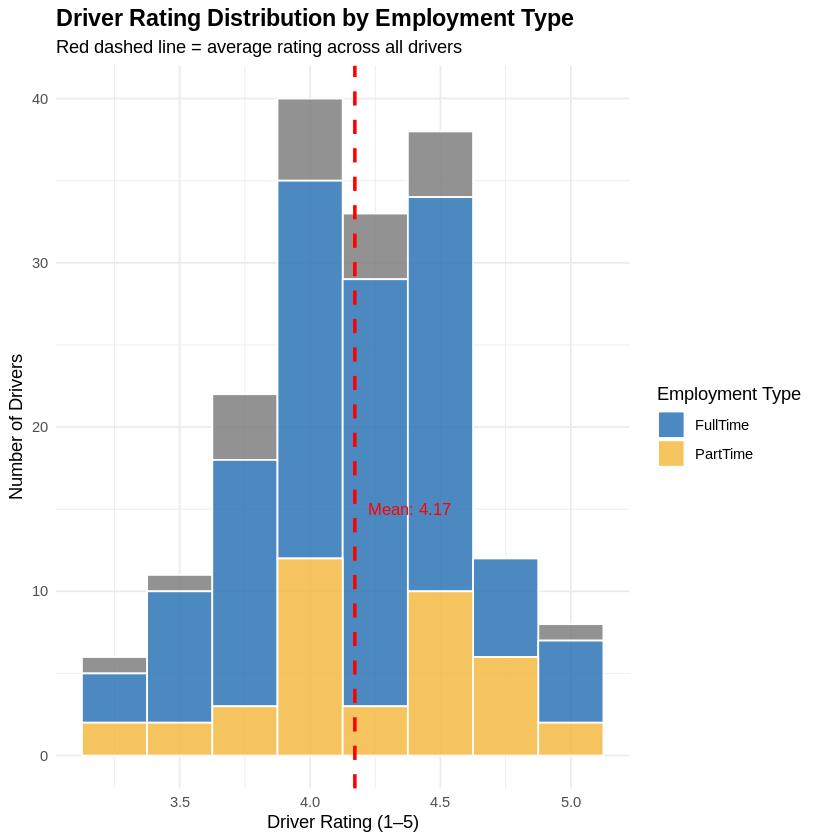

In [ ]:
ggplot(drivers, aes(x = driver_rating, fill = employment_type)) +
  geom_histogram(binwidth = 0.25, colour = "white", alpha = 0.85) +
  scale_fill_manual(values = c("FullTime" = "#2E75B6", "PartTime" = "#F4B942"),
                    name = "Employment Type") +
  geom_vline(xintercept = mean(drivers$driver_rating, na.rm = TRUE),
             linetype = "dashed", colour = "red", linewidth = 1) +
  annotate("text",
           x     = mean(drivers$driver_rating, na.rm = TRUE) + 0.05,
           y     = 15,
           label = paste0("Mean: ", round(mean(drivers$driver_rating, na.rm=TRUE), 2)),
           colour = "red", size = 3.5, hjust = 0) +
  labs(
    title    = "Driver Rating Distribution by Employment Type",
    subtitle = "Red dashed line = average rating across all drivers",
    x        = "Driver Rating (1–5)",
    y        = "Number of Drivers"
  ) +
  theme_minimal() +
  theme(plot.title = element_text(face = "bold", size = 14))

Final Summary Print

In [ ]:
cat("========================================\n")
cat("       STEP 4 — R ANALYTICS COMPLETE    \n")
cat("========================================\n\n")

cat("Key Findings:\n\n")

cat("1. ORDER VALUE:\n")
cat(sprintf("   Highest avg order value: %s (£%.2f)\n",
    order_stats$service_type[1], order_stats$mean_value[1]))
cat(sprintf("   Lowest  avg order value: %s (£%.2f)\n",
    order_stats$service_type[nrow(order_stats)],
    order_stats$mean_value[nrow(order_stats)]))

cat("\n2. COMPLAINTS:\n")
cat(sprintf("   Total complaints in dataset : %d\n", nrow(complaints)))
cat(sprintf("   High severity complaints    : %d\n",
    sum(complaints$severity == "High", na.rm = TRUE)))
cat(sprintf("   Still Open                  : %d\n",
    sum(complaints$status == "Open", na.rm = TRUE)))

cat("\n3. DRIVERS:\n")
cat(sprintf("   Total drivers               : %d\n", nrow(drivers)))
cat(sprintf("   Average driver rating       : %.2f\n",
    mean(drivers$driver_rating, na.rm = TRUE)))

cat("\n✅ All Step 4 analysis complete\n")

       STEP 4 — R ANALYTICS COMPLETE    

Key Findings:

1. ORDER VALUE:
   Highest avg order value: Passenger (£96.07)
   Lowest  avg order value: Medical (£87.14)

2. COMPLAINTS:
   Total complaints in dataset : 320
   High severity complaints    : 77
   Still Open                  : 56

3. DRIVERS:
   Total drivers               : 170
   Average driver rating       : 4.17

✅ All Step 4 analysis complete
